In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
image_paths = [r"C:\Users\fArInAz\Project1\License_plate.jpg"]
for path in image_paths:
    
    img = cv2.imread(path)
    
    if img is None:
        print("Image not found:", path)

    else:
        print("Image loaded succrssfully:", path)

Image loaded succrssfully: C:\Users\fArInAz\Project1\License_plate.jpg


In [4]:
import os
print(" files inside this folder:")
for f in os.listdir():
    print(f)

 files inside this folder:
.ipynb_checkpoints
License_plate.jpg
samart-truck-trip-prediction.ipynb
Truck_license_plate.jpg
vehicle-license-plate-recognition-system.ipynb


In [5]:
import os
print(os.getcwd())

C:\Users\fArInAz\Project1


In [6]:
for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        print("Image not found:", path)
        continue

In [7]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

def detect_and_crop_plate(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print("❌ Image not found:", img_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.bilateralFilter(gray, 11, 17, 17)
    edged = cv2.Canny(blurred, 30, 200)

    contours, _ = cv2.findContours(edged, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:30]

    plate_contour = None

    for c in contours:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)

        if len(approx) == 4:  
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)

            if 2 < aspect_ratio < 6:  
                plate_contour = approx
                break

    if plate_contour is None:
        print(f"🚫 No plate detected in {img_path}")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original Image (No Plate Found)")
        plt.axis("off")
        plt.show()
        return None

    
    rect = cv2.minAreaRect(plate_contour)
    box = cv2.boxPoints(rect)
    box = box.astype(int)

    
    mask = np.zeros(gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [box], -1, 255, -1)

    
    plate_only = cv2.bitwise_and(gray, gray, mask=mask)

    
    xs = box[:, 0]
    ys = box[:, 1]
    cropped_plate = plate_only[min(ys):max(ys), min(xs):max(xs)]

    
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cropped_plate, cmap="gray")
    plt.title("Detected Plate (Full)")
    plt.axis("off")

    plt.show()

    return cropped_plate

Processing: C:\Users\fArInAz\Project1\License_plate.jpg


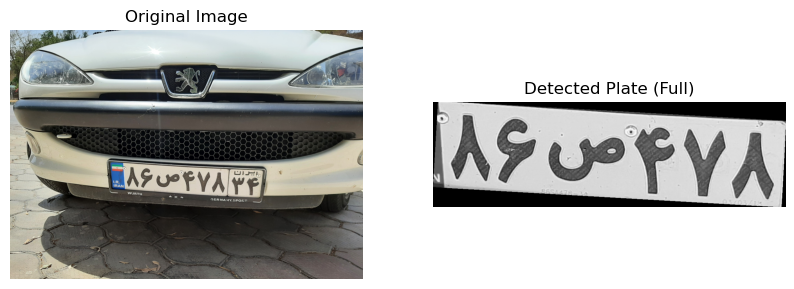

In [8]:
for path in image_paths:
    print("Processing:", path)
    detect_and_crop_plate(path)

In [23]:
import cv2
import pytesseract 
import matplotlib.pyplot as plt

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

image = cv2.imread(r"C:\Users\fArInAz\Project1\License_plate.jpg")

if image is None:
    print("Error: Could not load the image. Check the file path!")

else:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    text = pytesseract.image_to_string(gray, config="--psm 6")

    print("Extracted Text:")
    print(text)

Extracted Text:
IRAN 7
CEO WURTH ee ae GERwaAncee



In [24]:
from PIL import Image
image = Image.open(r"C:\Users\fArInAz\Project1\License_plate.jpg")
img.size

29312712